In [220]:
#real world data example

In [221]:
#import of packages

import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display #print data frames well


print("ok")

ok


In [222]:
#estimators

#fast realized variance estimator

def fast_realized_variance(observed_increments):
    """
    Calculate realized variance Sigma_hat from log-price increments. As the calculation is vectorized, it should be fast.

    Parameters
    ----------
    observed_increments : numpy.ndarray
        Matrix with the increments of the log-prices on the interval [(i-1)*sampling_interval,i*sampling_interval]
        in the i-th row.

    Returns
    -------
    Sigma_hat : numpy.ndarray
        Matrix estimator of the underlying QV.

    """

    Sigma_hat=(observed_increments.T) @ observed_increments

    return Sigma_hat



#prv estimator if RV and lambda are known

def penalized_realized_variance_for_given_lambda_and_RV(Sigma_hat, tuning_parameter_lambda):
    """
    Calculate the PRV estimator Sigma_hat_lambda from the RV estimator and the tuning parameter lambda.

    Parameters
    ----------
    Sigma_hat : numpy.ndarray
        Realized variance estimator.
    tuning_parameter_lambda : int
        The tuning parameter lambda used as prefactor of the nuclear norm penalization.

    Returns
    -------
    Sigma_hat_lambda : numpy.ndarray
        Matrix estimator of the underlying QV.
    rank_of_prv : int
        Rank of the PRV estimator matrix.

    """
    d=Sigma_hat.shape[0]
    Sigma_hat_lambda=np.zeros((d,d))
    rank_of_prv=30 #if all shrinked eigenvalues are positive, the else below is never reached, so need rank d then

    #prv calculation (with Theorem 3.6 in the thesis)

    eigvals_rv_ascending, U = np.linalg.eigh(Sigma_hat)
    # rv symmetric, hence, it returns ascending eigvals and eigvecs in columns of U

    eigvals_rv=np.flip(eigvals_rv_ascending) #eigenvals now in descending order

    for z in range(d):
        if eigvals_rv[z]>(tuning_parameter_lambda/2):
            Sigma_hat_lambda+=(eigvals_rv[z]-(tuning_parameter_lambda/2))* ((U[:,d-z-1].reshape(d,1)) @ (U[:,d-z-1].reshape(d,1).T))
            #attention: since eigenvales are flipped, the index in U is d-z-1, not z!
        else:
            #as descending, all others are also smaller (lambda_final/2)
            rank_of_prv=z
            break


    return Sigma_hat_lambda, rank_of_prv


#subsampling procedure for the data-driven selection of lambda

def lambda_selection_via_subsampling_procedure(observed_increments, L_lambda=6):
    """
    Calculate the tuning parameter lambda_subsam by an subsmapling procedure following section 2.4 in Christensen et al. (2022).

    Parameters
    ----------
    observed_increments : numpy.ndarray
        Matrix with the increments of the log-prices on the interval [(i-1)*sampling_interval,i*sampling_interval]
        in the i-th row.
    L_lambda : int
        The hyperparameter L_lambda defines the number of subsamples used in the choice of the tuning parameter lambda.

    Returns
    -------
    lambda_subsam: float
        Tuning parameter that is applied for PRV.

    """
    n,d=observed_increments.shape
    sigma_hat_rv=fast_realized_variance(observed_increments)

    #subsampling for choice of lambda
    lambdas=np.zeros(L_lambda)

    for l in range(L_lambda):
        observed_increments_subsample=observed_increments[np.arange(l,n,L_lambda),:] #start, stop, step
        #l, l+L, l+2L,...,(n/L-1)*L+L
        subsample_rv=L_lambda*fast_realized_variance(observed_increments_subsample) #equation (2.24) in Christensen et al. (2022)
        lambdas[l]=(2/np.sqrt(L_lambda))*np.linalg.norm((subsample_rv - sigma_hat_rv), ord=2)
        #equation (2.25) in Christensen et al. (2022), spectral norm here order 2

    lambda_subsam=np.mean(lambdas) #equation (2.26) in Christensen et al. (2022)

    return lambda_subsam


print("ok")

ok


In [223]:
#load data

#local

#print names of data files
#print(os.listdir(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data'))

#load
#1) Apple Inc. (tech) 
original_data_AAPL=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\AAPL.csv', 
                               sep=";")
#original_data_AAPL.head()

#2) Amazon.com Inc. (e-commerce and tech) 
original_data_AMZN=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\AMZN.csv', 
                               sep=";")
#original_data_AMZN.head()

#3) Exelon Corporation (energy supplier) 
original_data_EXC=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\EXC.csv', 
                               sep=";")
#original_data_EXC.head()

#4)Alphabet Inc. (Google) (tech) 
original_data_GOOG=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\GOOG.csv', 
                               sep=";")
#original_data_GOOG.head()

#5)Intel Corporation (tech, semiconductor chips) 
original_data_INTC=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\INTC.csv', 
                               sep=";")
#original_data_INTC.head()

#6)Johnson & Johnson (healthcare) 
original_data_JNJ=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\JNJ.csv', 
                               sep=";")
#original_data_JNJ.head()

#7)JPMorgan Chase & Co. (finance) 
original_data_JPM=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\JPM.csv', 
                               sep=";")
#original_data_JPM.head()

#8)Minnesota Mining and Manufacturing Company (conglomerate) 
original_data_MMM=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\MMM.csv', 
                               sep=";")
#original_data_MMM.head()

#9)Microsoft Corporation (tech) 
original_data_MSFT=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\MSFT.csv', 
                               sep=";")
#original_data_MSFT.head()

#10)NVIDIA Corporation (tech, GPUs) 
original_data_NVDA=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\NVDA.csv', 
                               sep=";")
#original_data_NVDA.head()

#11)The Procter & Gamble Company (consumer goods, household and personal care) 
original_data_PG=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\PG.csv', 
                               sep=";")
#original_data_PG.head()

#12)SPDR S&P 500 ETF Trust (a large ETF, replicates the performance of the S&P 500 index) 
original_data_SPY=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\SPY.csv', 
                               sep=";")
#original_data_SPY.head()

#13)Tesla, Inc. (electric vehicles) 
original_data_TSLA=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\TSLA.csv', 
                               sep=";")
#original_data_TSLA.head()

#14)Exxon Mobil Corporation (energy) 
original_data_XOM=pd.read_csv(r'C:\Users\Daniel\Desktop\MA\Python\real-world-data\Implementierung\Daten\Data_example_data\XOM.csv', 
                               sep=";")
#print data format
print("head of XOM data:")
display(original_data_XOM.head())


#notes: TSLA 29.06.2010 Initial Public Offering.

#############################################################################################################################
##google colab
#from google.colab import drive
#drive.mount('/content/drive')

#print(os.listdir('/content/drive/MyDrive'))

##Apple Inc.
#data_AAPL=pd.read_csv("/content/drive/MyDrive/Kopie von Mappe1_AAPL.csv", sep=";")
#data_AAPL.head()

##Tesla
#data_TSLA=pd.read_csv("/content/drive/MyDrive/Mappe1_TSLA.csv", sep=";")
#data_TSLA.head()

print("ok")

head of XOM data:


,Datum,Uhrzeit,Value
0,27.06.2007,950445,813100
1,27.06.2007,9533876,810800
2,27.06.2007,9566883,809700
3,27.06.2007,9600614,811300
4,27.06.2007,9633832,812200


ok


In [224]:
#data preparation

#drop duplicates (e.g. TSLA 29.06.2010 Initial Public Offering)
#if for the same day and same time exist several values, only keep the first value
data_no_duplicates_AAPL=(
    original_data_AAPL
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)

#transform strings in Datum to dates, at the moment the day is first part of the date
data_no_duplicates_AAPL.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_AAPL["Datum"], dayfirst=True)
#add log-Value column
data_no_duplicates_AAPL.loc[:,"log_value"]=np.log(data_no_duplicates_AAPL["Value"])
print("head of Apple data after processing:")
display(data_no_duplicates_AAPL.head())
print("data shapes before dropping duplicates and after:")
print("AAPL", original_data_AAPL.shape,data_no_duplicates_AAPL.shape)

data_no_duplicates_AMZN=(
    original_data_AMZN
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_AMZN.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_AMZN["Datum"], dayfirst=True)
data_no_duplicates_AMZN.loc[:,"log_value"]=np.log(data_no_duplicates_AMZN["Value"])
print("AMZN", original_data_AMZN.shape,data_no_duplicates_AMZN.shape)

data_no_duplicates_EXC=(
    original_data_EXC
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_EXC.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_EXC["Datum"], dayfirst=True)
data_no_duplicates_EXC.loc[:,"log_value"]=np.log(data_no_duplicates_EXC["Value"])
print("EXC", original_data_EXC.shape,data_no_duplicates_EXC.shape)

data_no_duplicates_GOOG=(
    original_data_GOOG
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_GOOG.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_GOOG["Datum"], dayfirst=True)
data_no_duplicates_GOOG.loc[:,"log_value"]=np.log(data_no_duplicates_GOOG["Value"])
print("GOOG", original_data_GOOG.shape,data_no_duplicates_GOOG.shape)

data_no_duplicates_INTC=(
    original_data_INTC
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_INTC.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_INTC["Datum"], dayfirst=True)
data_no_duplicates_INTC.loc[:,"log_value"]=np.log(data_no_duplicates_INTC["Value"])
print("INTC", original_data_INTC.shape,data_no_duplicates_INTC.shape)

data_no_duplicates_JNJ=(
    original_data_JNJ
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_JNJ.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_JNJ["Datum"], dayfirst=True)
data_no_duplicates_JNJ.loc[:,"log_value"]=np.log(data_no_duplicates_JNJ["Value"])
print("JNJ", original_data_JNJ.shape,data_no_duplicates_JNJ.shape)

data_no_duplicates_JPM=(
    original_data_JPM
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_JPM.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_JPM["Datum"], dayfirst=True)
data_no_duplicates_JPM.loc[:,"log_value"]=np.log(data_no_duplicates_JPM["Value"])
print("JPM", original_data_JPM.shape,data_no_duplicates_JPM.shape)

data_no_duplicates_MMM=(
    original_data_MMM
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_MMM.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_MMM["Datum"], dayfirst=True)
data_no_duplicates_MMM.loc[:,"log_value"]=np.log(data_no_duplicates_MMM["Value"])
print("MMM", original_data_MMM.shape,data_no_duplicates_MMM.shape)

data_no_duplicates_MSFT=(
    original_data_MSFT
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_MSFT.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_MSFT["Datum"], dayfirst=True)
data_no_duplicates_MSFT.loc[:,"log_value"]=np.log(data_no_duplicates_MSFT["Value"])
print("MSFT", original_data_MSFT.shape,data_no_duplicates_MSFT.shape)

data_no_duplicates_NVDA=(
    original_data_NVDA
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_NVDA.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_NVDA["Datum"], dayfirst=True)
data_no_duplicates_NVDA.loc[:,"log_value"]=np.log(data_no_duplicates_NVDA["Value"])
print("NVDA", original_data_NVDA.shape,data_no_duplicates_NVDA.shape)

data_no_duplicates_PG=(
    original_data_PG
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_PG.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_PG["Datum"], dayfirst=True)
data_no_duplicates_PG.loc[:,"log_value"]=np.log(data_no_duplicates_PG["Value"])
print("PG", original_data_PG.shape,data_no_duplicates_PG.shape)

data_no_duplicates_SPY=(
    original_data_SPY
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_SPY.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_SPY["Datum"], dayfirst=True)
data_no_duplicates_SPY.loc[:,"log_value"]=np.log(data_no_duplicates_SPY["Value"])
print("SPY", original_data_SPY.shape,data_no_duplicates_SPY.shape)

data_no_duplicates_TSLA=(
    original_data_TSLA
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_TSLA.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_TSLA["Datum"], dayfirst=True)
data_no_duplicates_TSLA.loc[:,"log_value"]=np.log(data_no_duplicates_TSLA["Value"])
print("TSLA", original_data_TSLA.shape,data_no_duplicates_TSLA.shape)

data_no_duplicates_XOM=(
    original_data_XOM
    .drop_duplicates(subset=["Datum","Uhrzeit"], keep="first")
    .copy()#make copy not only a view
)
data_no_duplicates_XOM.loc[:,"Datum"]=pd.to_datetime(data_no_duplicates_XOM["Datum"], dayfirst=True)
data_no_duplicates_XOM.loc[:,"log_value"]=np.log(data_no_duplicates_XOM["Value"])
print("XOM", original_data_XOM.shape,data_no_duplicates_XOM.shape)

#JNJ has many duplicates! Later it is typically excluded, to get completely observed days.
print("ok")


head of Apple data after processing:


,Datum,Uhrzeit,Value,log_value
0,2007-06-27 00:00:00,9500016,1206000,14.002820
1,2007-06-27 00:00:00,9533367,1202000,13.999497
2,2007-06-27 00:00:00,9566706,1199000,13.996998
3,2007-06-27 00:00:00,960007,1203600,14.000828
4,2007-06-27 00:00:00,9633694,1207100,14.003731


data shapes before dropping duplicates and after:
AAPL (884642, 3) (884293, 4)
AMZN (885516, 3) (884903, 4)
EXC (884836, 3) (869674, 4)
GOOG (817992, 3) (815862, 4)
INTC (885512, 3) (880263, 4)
JNJ (890801, 3) (695628, 4)
JPM (885641, 3) (884967, 4)
MMM (884807, 3) (882612, 4)
MSFT (877768, 3) (875992, 4)
NVDA (885754, 3) (874205, 4)
PG (885512, 3) (883774, 4)
SPY (887273, 3) (887101, 4)
TSLA (739386, 3) (731855, 4)
XOM (885442, 3) (885042, 4)
ok


In [225]:
#group by trading days

#tickers
#['AAPL.csv', 'AMZN.csv', 'EXC.csv', 'GOOG.csv', 'INTC.csv', 'JNJ.csv', 'JPM.csv', 'MMM.csv', 
#'MSFT.csv', 'NVDA.csv', 'PG.csv', 'SPY.csv', 'TSLA.csv', 'XOM.csv']]


#AAPL
data_grouped_AAPL=(
    data_no_duplicates_AAPL
    .groupby(by="Datum", sort=False)["log_value"] 
    #collect for each date all times and log_values, keep ordering of days like in df before, but only consider log values then
    .apply(list) #transform the log values into a list
    .reset_index(name="log_value") # generate a data frame again
)
data_grouped_AAPL["number observations"]=data_grouped_AAPL["log_value"].apply(len) 
#add column that counts number of observed log-prices per day
#print(data_grouped_AAPL.head())

data_processed_AAPL=data_grouped_AAPL[data_grouped_AAPL["number observations"]==78*5/2] 
#only uses days that have observations for all 2 min time slots (78 for 5 min, means 78*5 for 1 min, implies 78*5/2 for 2 min)
print("head of grouped Apple data with completely observed days:")
display(data_processed_AAPL.head())
print("data shapes before and after dropping incomplete days:")
print("AAPL", data_grouped_AAPL.shape, data_processed_AAPL.shape)


#AMZN
data_grouped_AMZN=(
    data_no_duplicates_AMZN
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_AMZN["number observations"]=data_grouped_AMZN["log_value"].apply(len) 
data_processed_AMZN=data_grouped_AMZN[data_grouped_AMZN["number observations"]==78*5/2] 
print("AMZN", data_grouped_AMZN.shape, data_processed_AMZN.shape)

#EXC
data_grouped_EXC=(
    data_no_duplicates_EXC
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_EXC["number observations"]=data_grouped_EXC["log_value"].apply(len) 
data_processed_EXC=data_grouped_EXC[data_grouped_EXC["number observations"]==78*5/2] 
print("EXC", data_grouped_EXC.shape, data_processed_EXC.shape)

# GOOG
data_grouped_GOOG=(
    data_no_duplicates_GOOG
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_GOOG["number observations"]=data_grouped_GOOG["log_value"].apply(len) 
data_processed_GOOG=data_grouped_GOOG[data_grouped_GOOG["number observations"]==78*5/2] 
print("GOOG", data_grouped_GOOG.shape, data_processed_GOOG.shape)

# INTC
data_grouped_INTC=(
    data_no_duplicates_INTC
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_INTC["number observations"]=data_grouped_INTC["log_value"].apply(len) 
data_processed_INTC=data_grouped_INTC[data_grouped_INTC["number observations"]==78*5/2] 
print("INTC", data_grouped_INTC.shape, data_processed_INTC.shape)

# JNJ
data_grouped_JNJ=(
    data_no_duplicates_JNJ
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_JNJ["number observations"]=data_grouped_JNJ["log_value"].apply(len) 
data_processed_JNJ=data_grouped_JNJ[data_grouped_JNJ["number observations"]==78*5/2] 
print("JNJ", data_grouped_JNJ.shape, data_processed_JNJ.shape)

# JPM
data_grouped_JPM=(
    data_no_duplicates_JPM
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_JPM["number observations"]=data_grouped_JPM["log_value"].apply(len) 
data_processed_JPM=data_grouped_JPM[data_grouped_JPM["number observations"]==78*5/2] 
print("JPM", data_grouped_JPM.shape, data_processed_JPM.shape)

# MMM
data_grouped_MMM=(
    data_no_duplicates_MMM
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_MMM["number observations"]=data_grouped_MMM["log_value"].apply(len) 
data_processed_MMM=data_grouped_MMM[data_grouped_MMM["number observations"]==78*5/2] 
print("MMM", data_grouped_MMM.shape, data_processed_MMM.shape)

# MSFT
data_grouped_MSFT=(
    data_no_duplicates_MSFT
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_MSFT["number observations"]=data_grouped_MSFT["log_value"].apply(len) 
data_processed_MSFT=data_grouped_MSFT[data_grouped_MSFT["number observations"]==78*5/2] 
print("MSFT", data_grouped_MSFT.shape, data_processed_MSFT.shape)


# NVDA
data_grouped_NVDA=(
    data_no_duplicates_NVDA
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_NVDA["number observations"]=data_grouped_NVDA["log_value"].apply(len) 
data_processed_NVDA=data_grouped_NVDA[data_grouped_NVDA["number observations"]==78*5/2] 
print("NVDA", data_grouped_NVDA.shape, data_processed_NVDA.shape)


# PG
data_grouped_PG=(
    data_no_duplicates_PG
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_PG["number observations"]=data_grouped_PG["log_value"].apply(len) 
data_processed_PG=data_grouped_PG[data_grouped_PG["number observations"]==78*5/2] 
print("PG", data_grouped_PG.shape, data_processed_PG.shape)

# SPY
data_grouped_SPY=(
    data_no_duplicates_SPY
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_SPY["number observations"]=data_grouped_SPY["log_value"].apply(len) 
data_processed_SPY=data_grouped_SPY[data_grouped_SPY["number observations"]==78*5/2] 
print("SPY", data_grouped_SPY.shape, data_processed_SPY.shape)

# TSLA
data_grouped_TSLA=(
    data_no_duplicates_TSLA
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_TSLA["number observations"]=data_grouped_TSLA["log_value"].apply(len) 
data_processed_TSLA=data_grouped_TSLA[data_grouped_TSLA["number observations"]==78*5/2] 
print("TSLA", data_grouped_TSLA.shape, data_processed_TSLA.shape)

# XOM
data_grouped_XOM=(
    data_no_duplicates_XOM
    .groupby(by="Datum", sort=False)["log_value"] 
    .apply(list) 
    .reset_index(name="log_value")
)
data_grouped_XOM["number observations"]=data_grouped_XOM["log_value"].apply(len) 
data_processed_XOM=data_grouped_XOM[data_grouped_XOM["number observations"]==78*5/2] 
print("XOM", data_grouped_XOM.shape, data_processed_XOM.shape)


#note: EXC only 1905 fully observed days. TSLA 2836 at least. Probably, EXC not traded enough. 
#print(data_grouped_EXC.head())
#Later EXC is typically excluded, to get completely observed days.

print("ok")

head of grouped Apple data with completely observed days:


,Datum,log_value,number observations
0,2007-06-27,"[14.002819656269267, 13.99949739407729, 13.996...",195
1,2007-06-28,"[14.018369765975777, 14.01173501992722, 14.012...",195
2,2007-06-29,"[14.014033494096237, 14.01468923182465, 14.012...",195
3,2007-07-02,"[14.0067918561297, 14.010254634756786, 14.0089...",195
5,2007-07-05,"[14.068601185646436, 14.073248754042982, 14.08...",195


data shapes before and after dropping incomplete days:
AAPL (4589, 3) (4459, 3)
AMZN (4599, 3) (4201, 3)
EXC (4599, 3) (1905, 3)
GOOG (4236, 3) (3193, 3)
INTC (4600, 3) (3169, 3)
JNJ (3601, 3) (3064, 3)
JPM (4600, 3) (4138, 3)
MMM (4598, 3) (3423, 3)
MSFT (4557, 3) (3813, 3)
NVDA (4601, 3) (3258, 3)
PG (4601, 3) (3709, 3)
SPY (4601, 3) (4442, 3)
TSLA (3845, 3) (2836, 3)
XOM (4600, 3) (4291, 3)
ok


In [226]:
#create one big data frame

all_tickers = ["AMZN","EXC","GOOG","INTC","JNJ","JPM","MMM","MSFT","NVDA","PG","SPY","TSLA","XOM"]
all_data_frames = [data_processed_AMZN, data_processed_EXC, data_processed_GOOG, data_processed_INTC,
               data_processed_JNJ, data_processed_JPM, data_processed_MMM, data_processed_MSFT,
               data_processed_NVDA, data_processed_PG, data_processed_SPY, data_processed_TSLA,
               data_processed_XOM]
                   
unwanted_stock_positions=[1,2,4,11]  
#[]=all, [1]= not EXC
#[1,4,11] is not bad: 1582 days, [1,2,4,11]: 2014 days and 10 stocks (=final choice), [1,2,3,4,8,11]: 2536 days

tickers=[ticker for ind, ticker in enumerate(all_tickers) if ind not in unwanted_stock_positions]
data_frames=[frame for ind, frame in enumerate(all_data_frames) if ind not in unwanted_stock_positions]


data_all_stocks = data_processed_AAPL.copy()

for df, ticker in zip(data_frames, tickers): #merge the data of all stocks iteratively, as merge only works with 2 data frames
    data_all_stocks = data_all_stocks.merge(df, how="inner", on="Datum", suffixes=("", f"_{ticker}"))
    #find dates which are fully observed for both data frames (how="inner", 
    #then use this date as date and use all the log-values and observation numbers as columns

data_all_stocks.rename(columns={
    "log_value": "log_value_AAPL",
    "number observations": "number observations_AAPL",
}, inplace=True)
#rename AAPL columns


print("shape of final data frame - data_all_stocks: ",data_all_stocks.shape)
print("number of stocks: ", len(tickers)+1, " , number of days: ", data_all_stocks.shape[0] )
print("head of data_all_stocks: ")
display(data_all_stocks.head())

log_cols = [col for col in data_all_stocks.columns if col.startswith("log_value")]
print("names of the columns with log-values: ",log_cols)

#tickers
#['AAPL','AMZN','EXC','GOOG','INTC','JNJ','JPM','MMM','MSFT','NVDA','PG','SPY','TSLA','XOM']
print("ok")

shape of final data frame - data_all_stocks:  (2014, 21)
number of stocks:  10  , number of days:  2014
head of data_all_stocks: 


,Datum,log_value_AAPL,number observations_AAPL,log_value_AMZN,number observations_AMZN,log_value_INTC,number observations_INTC,log_value_JPM,number observations_JPM,log_value_MMM,...,log_value_MSFT,number observations_MSFT,log_value_NVDA,number observations_NVDA,log_value_PG,number observations_PG,log_value_SPY,number observations_SPY,log_value_XOM,number observations_XOM
0,2007-06-27,"[14.002819656269267, 13.99949739407729, 13.996...",195,"[13.420243274832556, 13.416226308931192, 13.42...",195,"[12.358364455872433, 12.360080458009522, 12.35...",195,"[13.086321606057064, 13.08963355278141, 13.089...",195,"[13.662126251064917, 13.666430334950121, 13.66...",...,"[12.590314117186711, 12.593713168725786, 12.59...",195,"[12.907187995739296, 12.913615706373852, 12.91...",195,"[13.322033572532897, 13.324324149450632, 13.32...",195,"[14.209172953953287, 14.209307861204756, 14.20...",195,"[13.60860938219593, 13.605776693559982, 13.604...",195
1,2007-07-10,"[14.068678822384179, 14.073248754042982, 14.07...",195,"[13.471751839292088, 13.46197354271647, 13.462...",195,"[12.420377248177179, 12.421990151752643, 12.41...",195,"[13.072963027109202, 13.072122160967583, 13.07...",195,"[13.687677186454389, 13.68676768207155, 13.685...",...,"[12.601487417784837, 12.601487417784837, 12.60...",195,"[13.013663960480988, 13.008298421116356, 13.00...",195,"[13.329702697173571, 13.324977637466047, 13.32...",195,"[14.23592995785425, 14.235141521545337, 14.235...",195,"[13.676248490630767, 13.671524707435893, 13.67...",195
2,2007-07-16,"[14.140488415159751, 14.142437381741956, 14.14...",195,"[13.507625778194974, 13.522480879185897, 13.52...",195,"[12.465740971526756, 12.465740971526756, 12.46...",195,"[13.12794775569823, 13.125558268300848, 13.125...",195,"[13.715690222682063, 13.712480657644731, 13.71...",...,"[12.603505581941073, 12.604177399232046, 12.60...",195,"[13.038981768465277, 13.037458870313884, 13.04...",195,"[13.345026813481661, 13.345186877507613, 13.34...",195,"[14.253700970685141, 14.25344285620994, 14.253...",195,"[13.71181532162551, 13.705695691957068, 13.707...",195
3,2007-07-17,"[14.139765610646895, 14.1398379146128, 14.1372...",195,"[13.511834595758144, 13.517778149658993, 13.51...",195,"[12.471125599921594, 12.469590090982656, 12.46...",195,"[13.125558268300848, 13.12356265797981, 13.123...",195,"[13.725914024152518, 13.71966023230744, 13.719...",...,"[12.611871031428459, 12.614865543731012, 12.61...",195,"[13.058144805077678, 13.062188654368258, 13.06...",195,"[13.353475098367715, 13.35506114152335, 13.352...",195,"[14.253894512829548, 14.254023520118638, 14.25...",195,"[13.710150042306449, 13.70992779538921, 13.714...",195
4,2007-07-20,"[14.163628999219886, 14.161508707238891, 14.16...",195,"[13.487423070877455, 13.478498175490552, 13.47...",195,"[12.440749432658057, 12.439562488898527, 12.43...",195,"[13.090872710312958, 13.077575194614194, 13.08...",195,"[13.715690222682063, 13.72152949449338, 13.718...",...,"[12.649154617209645, 12.64979646575543, 12.644...",195,"[13.036805489042683, 13.032657464319836, 13.03...",195,"[13.350932185363604, 13.34790405331826, 13.350...",195,"[14.253120119399005, 14.25286185493476, 14.252...",195,"[13.732237638770453, 13.735276165253667, 13.73...",195


names of the columns with log-values:  ['log_value_AAPL', 'log_value_AMZN', 'log_value_INTC', 'log_value_JPM', 'log_value_MMM', 'log_value_MSFT', 'log_value_NVDA', 'log_value_PG', 'log_value_SPY', 'log_value_XOM']
ok


In [227]:
#analysis of estimators

n=int(data_all_stocks.iloc[0,2])
print("number of observations per stock per day: n=", n)

number_of_stocks=int(len(log_cols))
d=number_of_stocks
print("number of observed stocks: d=", number_of_stocks)

number_of_days=data_all_stocks.shape[0]
print("number of observed days: ", number_of_days)

#arays to contain results
ranks_of_prv=np.zeros(number_of_days)
ranks_of_rv=np.zeros(number_of_days)

ev_rv=np.zeros((number_of_days,number_of_stocks))
ev_prv=np.zeros((number_of_days,number_of_stocks))

normed_ev_rv=np.zeros((number_of_days,number_of_stocks))
normed_ev_prv=np.zeros((number_of_days,number_of_stocks))


#iterate over all days(rows) in the data frame:
for idx, row in data_all_stocks.iterrows():
    log_values=np.zeros((n, number_of_stocks))   #observations with each column is a stock, each row a time
    for z in range(number_of_stocks):
        log_values[:, z]=np.array(data_all_stocks[log_cols[z]].iloc[idx]) 
    log_price_increments=np.diff(log_values, axis=0)   #caluclate the i-th row minus the (i-1)-th
    rv=fast_realized_variance(log_price_increments)
    ranks_of_rv[idx]=np.linalg.matrix_rank(rv)
    tuning_parameter_lambda=lambda_selection_via_subsampling_procedure(log_price_increments, L_lambda=6)
    prv, ranks_of_prv[idx]=penalized_realized_variance_for_given_lambda_and_RV(rv, tuning_parameter_lambda)
    ev_prv_day=np.sort(np.linalg.eigvalsh(prv))[::-1] #sorted in decreasing order: [::-1]
    ev_rv_day=np.sort(np.linalg.eigvalsh(rv))[::-1]
    ev_prv[idx,:]=ev_prv_day
    ev_rv[idx,:]=ev_rv_day
    normed_ev_prv[idx,:]=ev_prv_day/np.sum(ev_prv_day)
    normed_ev_rv[idx,:]=ev_rv_day/np.sum(ev_rv_day)
    
    if idx % (math.floor(number_of_days/10))==0:
        print(f'Finished day {idx+1} of {number_of_days}.')
        
#test
#print(log_values.shape, log_price_increments.shape) 
#print(log_values[0:5,0:5])
#print(log_price_increments[0:5,0:5])

print("ok")

number of observations per stock per day: n= 195
number of observed stocks: d= 10
number of observed days:  2014
Finished day 1 of 2014.
Finished day 202 of 2014.
Finished day 403 of 2014.
Finished day 604 of 2014.
Finished day 805 of 2014.
Finished day 1006 of 2014.
Finished day 1207 of 2014.
Finished day 1408 of 2014.
Finished day 1609 of 2014.
Finished day 1810 of 2014.
Finished day 2011 of 2014.
ok


In [228]:
#fast rank analysis
#which ranks of the prv appear how often
values, counts = np.unique(ranks_of_prv, return_counts=True)
relative_counts=counts/np.sum(counts)
print("prv ranks:", values)
print("how often:", counts)
print("relative:",relative_counts)
print("rank mean: ", np.mean(ranks_of_prv))
print("number of ranks in total (=observed days):", np.sum(counts))
print("ok")

prv ranks: [1. 2. 3. 4. 5. 6.]
how often: [373 543 835 222  38   3]
relative: [0.18520357 0.26961271 0.41459782 0.1102284  0.01886792 0.00148957]
rank mean:  2.512413108242304
number of ranks in total (=observed days): 2014
ok


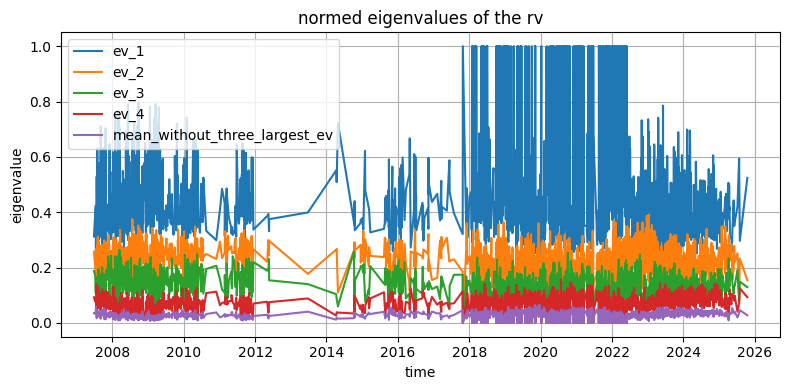

Problem: in 2018 to 2022 often the largest ev dominates extremely.
ok


In [229]:
#normed ev
eigenvalue_mean_rv_without_three_largest=np.mean(normed_ev_rv[:, 3:], axis=1)
x=data_all_stocks["Datum"].to_numpy()

plt.figure(figsize=(8, 4))
plt.plot(x,normed_ev_rv[:, 0], label='ev_1')
plt.plot(x,normed_ev_rv[:, 1], label='ev_2')
plt.plot(x,normed_ev_rv[:, 2], label='ev_3')
plt.plot(x,normed_ev_rv[:, 3], label='ev_4')
plt.plot(x,eigenvalue_mean_rv_without_three_largest, label='mean_without_three_largest_ev')

plt.yticks()

plt.title("normed eigenvalues of the rv")
plt.xlabel('time')
plt.ylabel('eigenvalue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print("Problem: in 2018 to 2022 often the largest ev dominates extremely.")
print("ok")

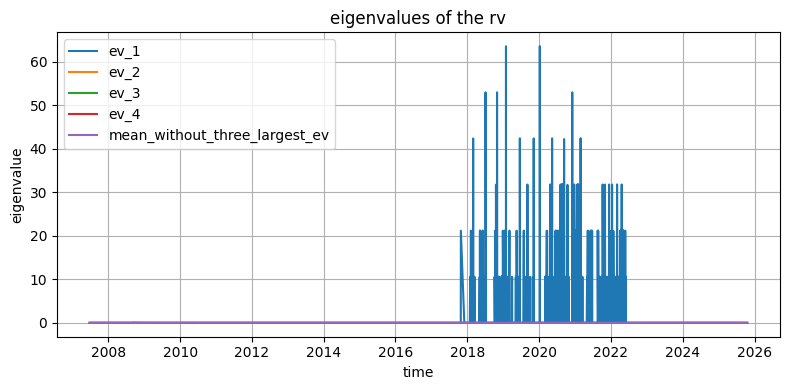

Problem: in 2018 to 2022 often the largest ev is extremely large.
Maybe there are jumps in the data, that lead to large increments and hence large ev of the rv matrices?
ok


In [230]:
#ev
eigenvalue_mean_rv_without_three_largest=np.mean(ev_rv[:, 3:], axis=1)
x=data_all_stocks["Datum"].to_numpy()

plt.figure(figsize=(8, 4))
plt.plot(x,ev_rv[:, 0], label='ev_1')
plt.plot(x,ev_rv[:, 1], label='ev_2')
plt.plot(x,ev_rv[:, 2], label='ev_3')
plt.plot(x,ev_rv[:, 3], label='ev_4')
plt.plot(x,eigenvalue_mean_rv_without_three_largest, label='mean_without_three_largest_ev')

plt.yticks()

plt.title("eigenvalues of the rv")
plt.xlabel('time')
plt.ylabel('eigenvalue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Problem: in 2018 to 2022 often the largest ev is extremely large.")
print("Maybe there are jumps in the data, that lead to large increments and hence large ev of the rv matrices?")

print("ok")

In [231]:
#describe the large ev1
large_ev_1_indices_analysis= np.where(ev_rv[:, 0]>10**(0))
print("for how many days the largest ev is extreemly large (> 1): ",np.shape(large_ev_1_indices_analysis)[1])
print("minimal value of these large ev1: ", np.min(ev_rv[large_ev_1_indices_analysis, 0]))
print("maximal value of the corresponding ev2: ", np.max(ev_rv[large_ev_1_indices_analysis, 1]))
print("minimal rank of the rv for all days: ",np.min(ranks_of_rv))

print("The days with large ev1 are excluded from the analysis in the following (they are not that many (approx. 8%)") 
print("And they appear only in one time interval (2017-2023), which indicates something unwanted/unnormal.")

print("ok")


for how many days the largest ev is extreemly large (> 1):  165
minimal value of these large ev1:  10.549662793923174
maximal value of the corresponding ev2:  0.026655705321208242
minimal rank of the rv for all days:  10.0
The days with large ev1 are excluded from the analysis in the following (they are not that many (approx. 8%)
And they appear only in one time interval (2017-2023), which indicates something unwanted/unnormal.
ok


In [232]:
#exclude days with extremely high ev1

large_ev_1_indices_matrix= (np.where(ev_rv[:, 0]>10**(-1))[0])
large_ev_1_indices=large_ev_1_indices_matrix.flatten()
print("shape of large_ev_1_indices:", large_ev_1_indices.shape)

dates_cleaned=data_all_stocks["Datum"].drop(large_ev_1_indices).reset_index(drop=True) 
#index is made new without missing values in between

ranks_of_prv_cleaned=np.delete(ranks_of_prv, large_ev_1_indices, axis=0)
ranks_of_rv_cleaned=np.delete(ranks_of_rv, large_ev_1_indices, axis=0)

ev_prv_cleaned=np.delete(ev_prv, large_ev_1_indices, axis=0)
ev_rv_cleaned=np.delete(ev_rv, large_ev_1_indices, axis=0)

normed_ev_prv_cleaned=np.delete(normed_ev_prv, large_ev_1_indices, axis=0)
normed_ev_rv_cleaned=np.delete(normed_ev_rv, large_ev_1_indices, axis=0)

print("shape of dates_cleaned:",dates_cleaned.shape)
print("shape of ev_prv_cleaned:", np.shape(ev_prv_cleaned))

print("ok")


shape of large_ev_1_indices: (165,)
shape of dates_cleaned: (1849,)
shape of ev_prv_cleaned: (1849, 10)
ok


In [233]:
#fast rank analysis
#which ranks of the prv appear how often
values, counts = np.unique(ranks_of_prv_cleaned, return_counts=True)
relative_counts=counts/np.sum(counts)
print("prv ranks:", values)
print("how often:", counts)
print("=> cleaning only deleted rank 1 prv estimators.")
print("relative:",relative_counts)
print("rank mean: ", np.mean(ranks_of_prv_cleaned))
print("number of ranks in total (=observed days):", np.sum(counts))
print("ok")

prv ranks: [1. 2. 3. 4. 5. 6.]
how often: [208 543 835 222  38   3]
=> cleaning only deleted rank 1 prv estimators.
relative: [0.11249324 0.29367226 0.45159546 0.1200649  0.02055165 0.0016225 ]
rank mean:  2.6473769605191997
number of ranks in total (=observed days): 1849
ok


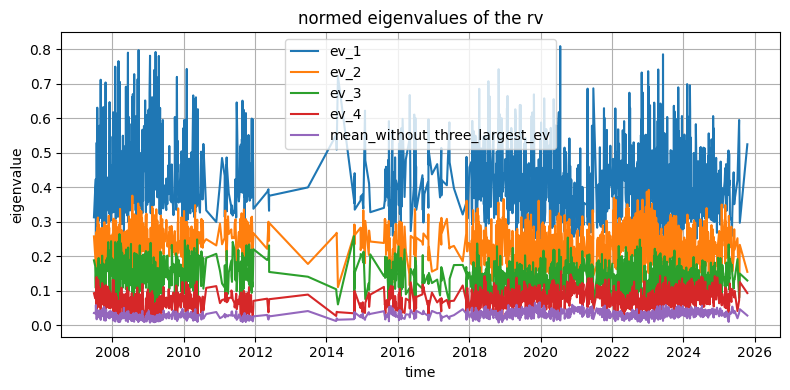

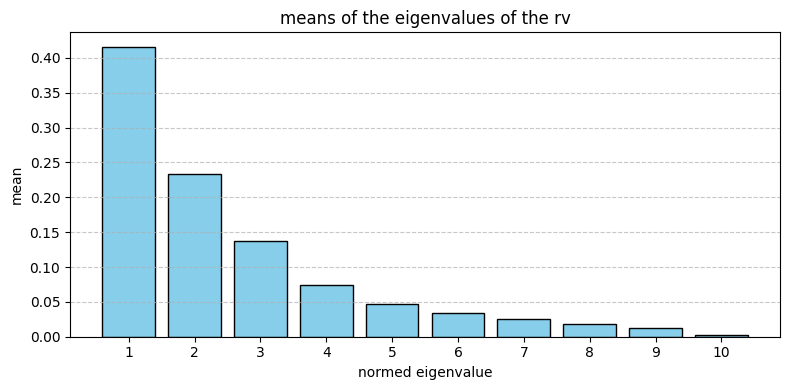

ok


In [234]:
#normed ev
eigenvalue_mean_rv_without_three_largest=np.mean(normed_ev_rv_cleaned[:, 3:], axis=1)
x=dates_cleaned

plt.figure(figsize=(8, 4))
plt.plot(x,normed_ev_rv_cleaned[:, 0], label='ev_1')
plt.plot(x,normed_ev_rv_cleaned[:, 1], label='ev_2')
plt.plot(x,normed_ev_rv_cleaned[:, 2], label='ev_3')
plt.plot(x,normed_ev_rv_cleaned[:, 3], label='ev_4')
plt.plot(x,eigenvalue_mean_rv_without_three_largest, label='mean_without_three_largest_ev')

plt.yticks()

plt.title("normed eigenvalues of the rv")
plt.xlabel('time')
plt.ylabel('eigenvalue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#means of normed ev

# Compute mean of each column
eigenvalue_means = np.mean(normed_ev_rv_cleaned, axis=0)

cols= np.arange(1, number_of_stocks+1)


plt.figure(figsize=(8, 4))
plt.bar(cols, eigenvalue_means, color='skyblue', edgecolor='black')


plt.xlabel('normed eigenvalue')
plt.ylabel('mean')
plt.title("means of the eigenvalues of the rv")
plt.xticks(cols) #ticks at the columns
plt.yticks()

plt.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines
plt.tight_layout()

plt.show()

print("ok")

observed days:  1849


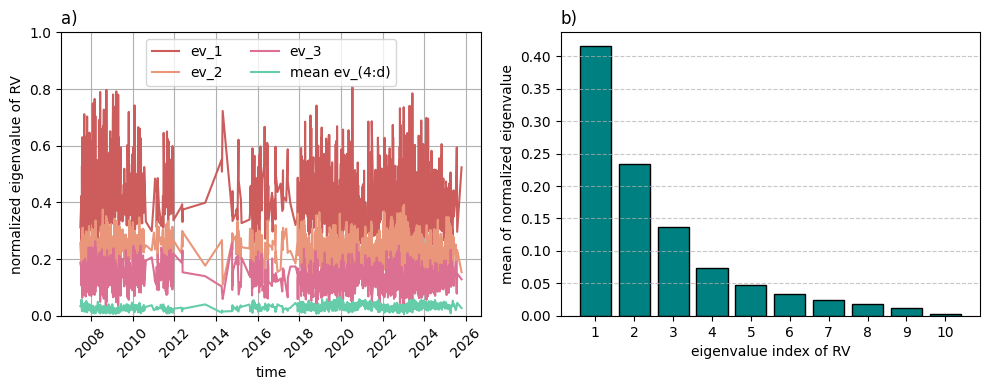

Observe: less distance between ev1 and ev2 as in Christensen 2022 (p.347). There, normalized ev_2 is in the mean only 0.1. 
Neglect time between 2010 and 2018, not enough data.
But outside of this, ev_1 shows the highest temporal variability (as in Christensen 2022 (p.347)).
In 2009 and 2020, the influence of ev_1 reaches its maxima. Correlated with financial crisis and Covid pandemic.
Also 2022-2023 turbulences, high interest rates and war in the Ukraine.
->Yacine Aït-Sahaliaa and Dacheng Xiu (p.299 of 'Principal Component Analysis of High-Frequency Data') also observe the maxima during crises.
ok


In [235]:
#plot for thesis

#rv normed eigenvalues and their means over time

print("observed days: ",normed_ev_rv_cleaned[:, 0].shape[0])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) normed ev time series
eigenvalue_mean_rv_without_three_largest=np.mean(normed_ev_rv_cleaned[:, 3:], axis=1)
x=dates_cleaned

ax1.plot(x,normed_ev_rv_cleaned[:, 0], label='ev_1', color="indianred")
ax1.plot(x,normed_ev_rv_cleaned[:, 1], label='ev_2', color="darksalmon")
ax1.plot(x,normed_ev_rv_cleaned[:, 2], label='ev_3', color="palevioletred") #darkkhaki
#ax1.plot(x,normed_ev_rv_cleaned[:, 3], label='ev_4', color="olive")
ax1.plot(x,eigenvalue_mean_rv_without_three_largest, label='mean ev_(4:d)', color="mediumaquamarine")

ax1.tick_params(axis='y')
ax1.set_xlabel("time")
ax1.set_ylabel("normalized eigenvalue of RV")
ax1.set_title("a) ", loc="left")
ax1.legend(ncol=2, loc="upper center")
ax1.grid(True)
ax1.tick_params(axis='x',rotation=45)
ax1.set_ylim(0,1)


#b) means of the time series

# Compute mean of each column
eigenvalue_means = np.mean(normed_ev_rv_cleaned, axis=0)

cols= np.arange(1, number_of_stocks+1)

ax2.bar(cols, eigenvalue_means, color='teal', edgecolor='black') #color='mediumaquamarine'

ax2.set_xlabel("eigenvalue index of RV")
ax2.set_ylabel("mean of normalized eigenvalue")
ax2.tick_params(axis='y')
ax2.tick_params(axis='x')
ax2.set_xticks(range(1, 11))

ax2.set_title("b)", loc="left")
ax2.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines

plt.tight_layout()
plt.show()

fig.savefig("real_data_eigenvalues_rv.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()

print("Observe: less distance between ev1 and ev2 as in Christensen 2022 (p.347). There, normalized ev_2 is in the mean only 0.1. ")
print("Neglect time between 2010 and 2018, not enough data.")
print("But outside of this, ev_1 shows the highest temporal variability (as in Christensen 2022 (p.347)).")
print("In 2009 and 2020, the influence of ev_1 reaches its maxima. Correlated with financial crisis and Covid pandemic.")
print("Also 2022-2023 turbulences, high interest rates and war in the Ukraine.")
print("->Yacine Aït-Sahaliaa and Dacheng Xiu (p.299 of 'Principal Component Analysis of High-Frequency Data') also observe the maxima during crises.")
print("ok")

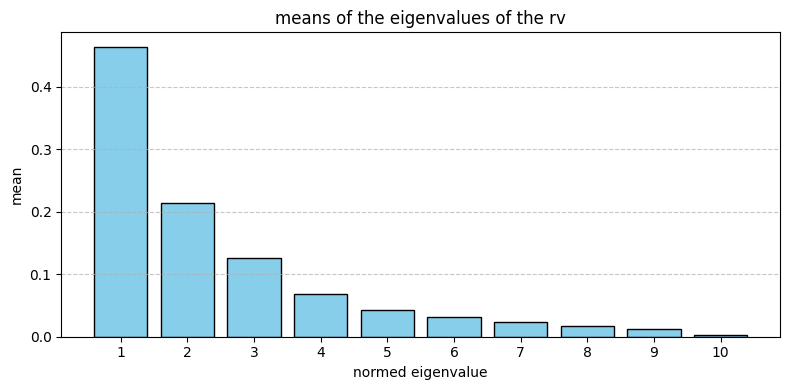

=>Cleaned and not cleaned look similar, only more rank 1 in the not cleaned case.
ok


In [236]:
#means not cleaned

# Compute mean of each column
eigenvalue_means = np.mean(normed_ev_rv, axis=0)

cols= np.arange(1, number_of_stocks+1)

plt.figure(figsize=(8, 4))
plt.bar(cols, eigenvalue_means, color='skyblue', edgecolor='black')


plt.xlabel('normed eigenvalue')
plt.ylabel('mean')
plt.title("means of the eigenvalues of the rv")
plt.xticks(cols) #ticks at the columns
plt.yticks()

plt.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines
plt.tight_layout()


plt.show()
print("=>Cleaned and not cleaned look similar, only more rank 1 in the not cleaned case.")

print("ok")

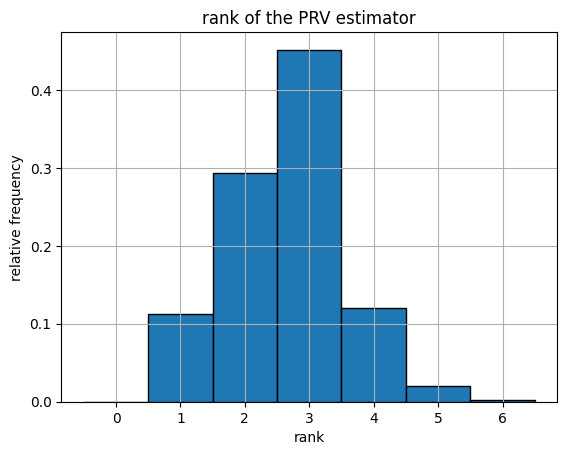

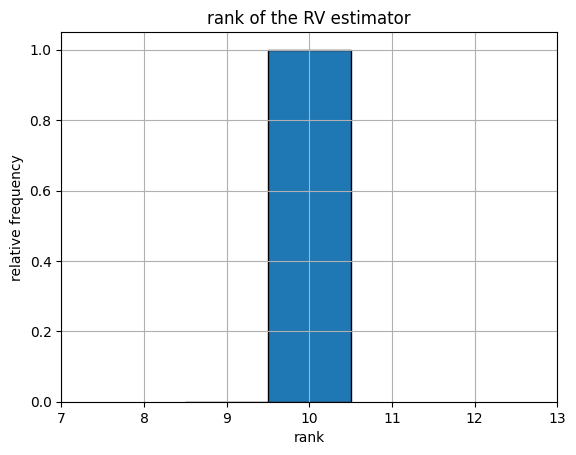

observed days:  1849
PRV rank fits well to Fama-French three factor interpretation of data
ok


In [237]:
#histogram of prv ranks
ranks=ranks_of_prv_cleaned
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 2) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
plt.hist(ranks, bins=bins_def, density=True, edgecolor='black')  #density for relative


plt.title('rank of the PRV estimator')
plt.xlabel("rank")
plt.ylabel("relative frequency")
plt.grid(True)

plt.show()

ranks=ranks_of_rv_cleaned
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 2) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
plt.hist(ranks, bins=bins_def, density=True, edgecolor='black')     #density for relative
plt.xticks(range(7,14))
plt.title("rank of the RV estimator")
plt.xlabel("rank")
plt.ylabel("relative frequency")
plt.grid(True)

plt.show()

print("observed days: ",ranks_of_prv_cleaned.shape[0])
print("PRV rank fits well to Fama-French three factor interpretation of data")

print("ok")

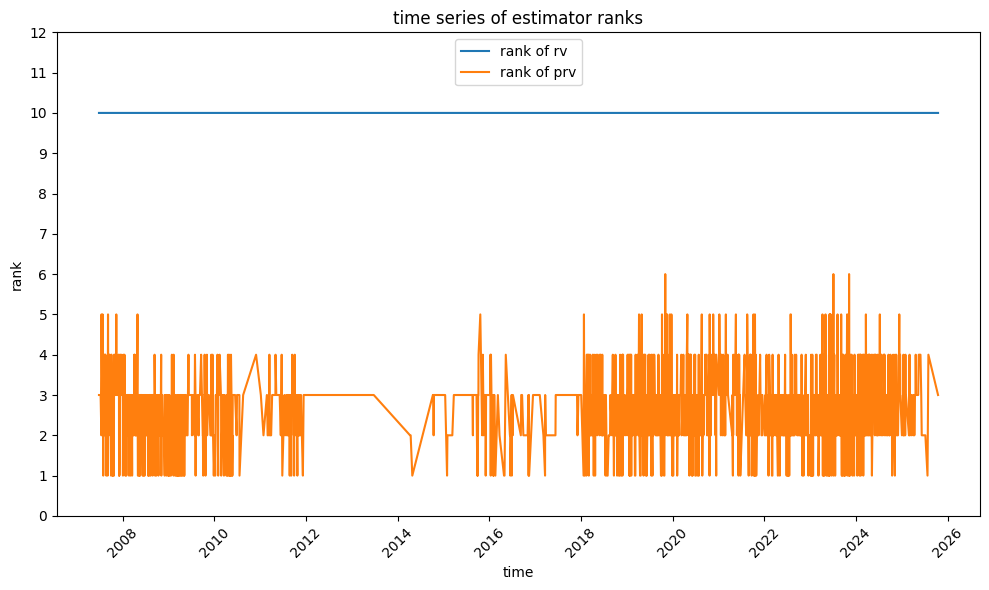

RV always has full rank. Need moving average to interpret prv rank, not stable enough without smoothing.
ok


In [238]:
#rank

#time series

plt.figure(figsize=(10,6))

x=dates_cleaned

y1=ranks_of_rv_cleaned

y2=ranks_of_prv_cleaned

plt.plot(x, y1, label="rank of rv")
plt.plot(x, y2, label="rank of prv")

plt.xlabel("time")
plt.ylabel("rank")
plt.title("time series of estimator ranks")
plt.legend(loc="upper center")
plt.yticks(range(0,13))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("RV always has full rank. Need moving average to interpret prv rank, not stable enough without smoothing.")

print("ok")

Number of considered days:  1849  (all days)
Number of business days in the period: 4808


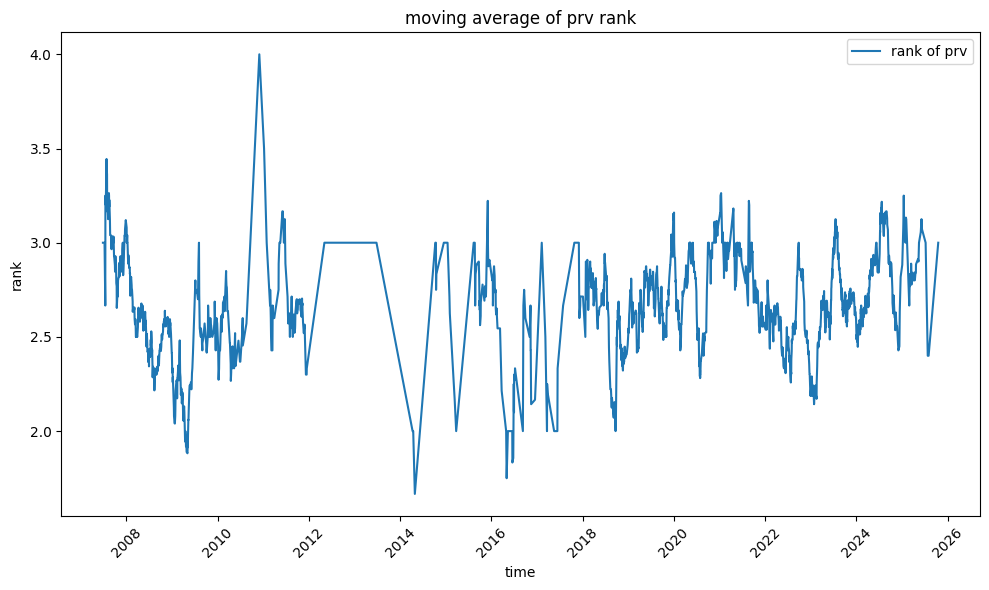

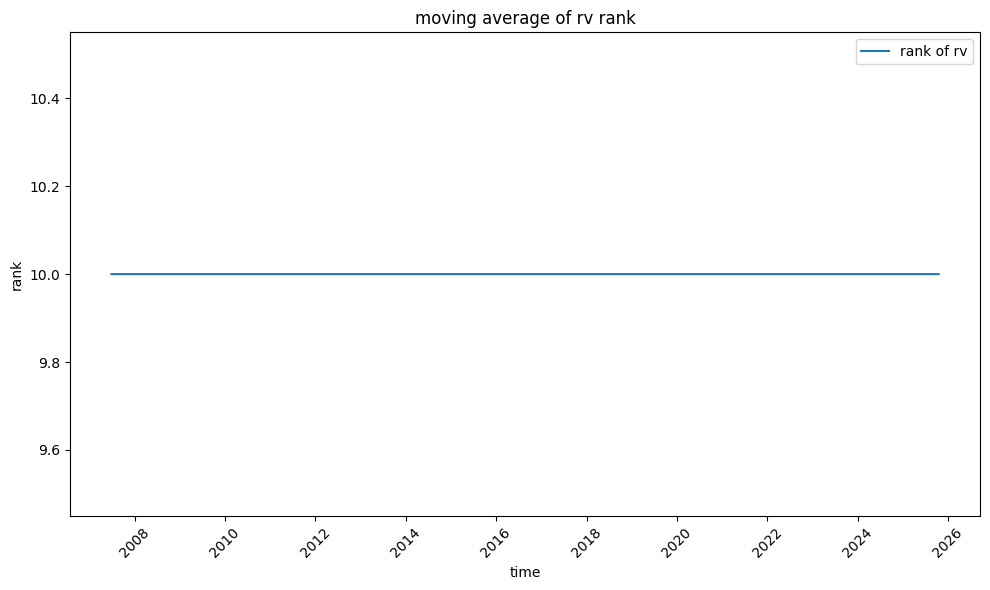

RV always has full rank. PRV rank is attains its minimium and drops below 2 in crises.
Neglect data between 2010 and 2018, then the minimums are attained at the financial crisis 2009, Covid 2020 and at the turbulences 2023.
ok


In [239]:
#rank with 30 days moving average
mov_av_data_full=data_all_stocks[["Datum"]].drop(large_ev_1_indices).reset_index(drop=True)
mov_av_data_full["ranks_prv"]=ranks_of_prv_cleaned
mov_av_data_full["ranks_rv"]=ranks_of_rv_cleaned


#only the time between
start_day="2007-06-27"
end_day="2025-12-01"
#=all days in the data

mov_av_data=mov_av_data_full[(mov_av_data_full["Datum"]>= start_day) & (mov_av_data_full["Datum"]<= end_day)].copy()
print("Number of considered days: ", mov_av_data.shape[0], " (all days)") 
print("Number of business days in the period:", np.busday_count(start_day, end_day))

mov_av_data = mov_av_data.sort_values("Datum") #sort for dates
mov_av_data = mov_av_data.set_index("Datum") # set dates as index

prv_rank_mov_avg=mov_av_data["ranks_prv"].rolling("60D").mean() 
#only consider 30 days before the date and take the average of the contained values
rv_rank_mov_avg=mov_av_data["ranks_rv"].rolling("60D").mean()

plt.figure(figsize=(10,6))

x=mov_av_data.index.to_numpy()
y1=prv_rank_mov_avg

plt.plot(x, y1, label="rank of prv")

plt.xlabel("time")
plt.ylabel("rank")
plt.title("moving average of prv rank")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

x=mov_av_data.index.to_numpy()
y1=rv_rank_mov_avg


plt.plot(x, y1, label="rank of rv")


plt.xlabel("time")
plt.ylabel("rank")
plt.title("moving average of rv rank")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("RV always has full rank. PRV rank is attains its minimium and drops below 2 in crises.")
print("Neglect data between 2010 and 2018, then the minimums are attained at the financial crisis 2009, Covid 2020 and at the turbulences 2023.")
print("ok")

Number of considered days:  358
Number of business days in the period: 587


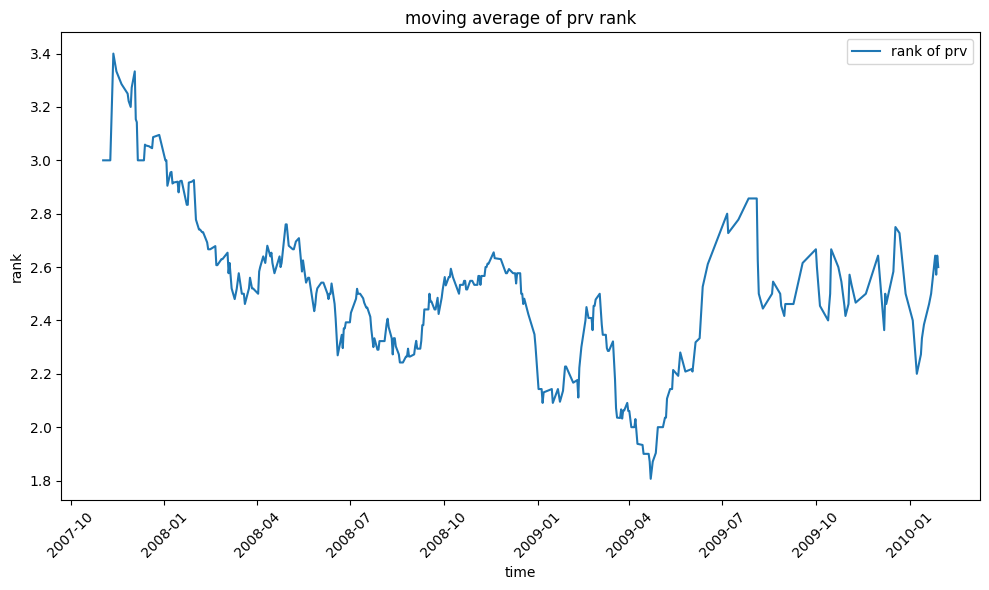

PRV rank is attains its minimium and drops close to 1 in financial crises.
ok


In [240]:
#rank with 30 days moving average
mov_av_data_full=data_all_stocks[["Datum"]].drop(large_ev_1_indices).reset_index(drop=True)
mov_av_data_full["ranks_prv"]=ranks_of_prv_cleaned
mov_av_data_full["ranks_rv"]=ranks_of_rv_cleaned


#only the time between
start_day="2007-11-01"
end_day="2010-01-30"

mov_av_data=mov_av_data_full[(mov_av_data_full["Datum"]>= start_day) & (mov_av_data_full["Datum"]<= end_day)].copy()
print("Number of considered days: ", mov_av_data.shape[0]) 
print("Number of business days in the period:", np.busday_count(start_day, end_day))

mov_av_data = mov_av_data.sort_values("Datum") #sort for dates
mov_av_data = mov_av_data.set_index("Datum") # set dates as index

prv_rank_mov_avg=mov_av_data["ranks_prv"].rolling("50D").mean() 
#only consider 30 days before the date and take the average of the contained values
rv_rank_mov_avg=mov_av_data["ranks_rv"].rolling("50D").mean()

plt.figure(figsize=(10,6))

x=mov_av_data.index.to_numpy()
y1=prv_rank_mov_avg

plt.plot(x, y1, label="rank of prv")

plt.xlabel("time")
plt.ylabel("rank")
plt.title("moving average of prv rank")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



print("PRV rank is attains its minimium and drops close to 1 in financial crises.")
print("ok")


Number of considered days:  386
Number of business days in the period: 696


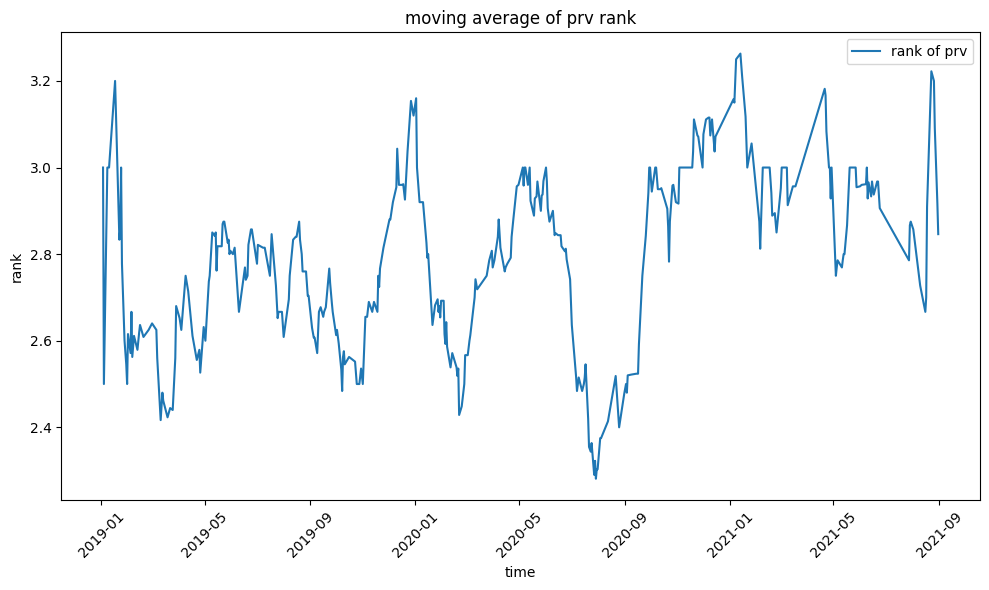

Corona crisis reduces rank, but still larger than 2.
ok


In [241]:
#rank with 30 days moving average
mov_av_data_full=data_all_stocks[["Datum"]].drop(large_ev_1_indices).reset_index(drop=True)
mov_av_data_full["ranks_prv"]=ranks_of_prv_cleaned
mov_av_data_full["ranks_rv"]=ranks_of_rv_cleaned


#only the time between
start_day="2019-01-01"
end_day="2021-09-01"

mov_av_data=mov_av_data_full[(mov_av_data_full["Datum"]>= start_day) & (mov_av_data_full["Datum"]<= end_day)].copy()

print("Number of considered days: ", mov_av_data.shape[0]) 
print("Number of business days in the period:", np.busday_count(start_day, end_day))

mov_av_data = mov_av_data.sort_values("Datum")
mov_av_data = mov_av_data.set_index("Datum")

prv_rank_mov_avg=mov_av_data["ranks_prv"].rolling("60D").mean()
rv_rank_mov_avg=mov_av_data["ranks_rv"].rolling("60D").mean()

plt.figure(figsize=(10,6))

x=mov_av_data.index.to_numpy()
y2=prv_rank_mov_avg

plt.plot(x, y2, label="rank of prv")

plt.xlabel("time")
plt.ylabel("rank")
plt.title("moving average of prv rank")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Corona crisis reduces rank, but still larger than 2.")
print("ok")

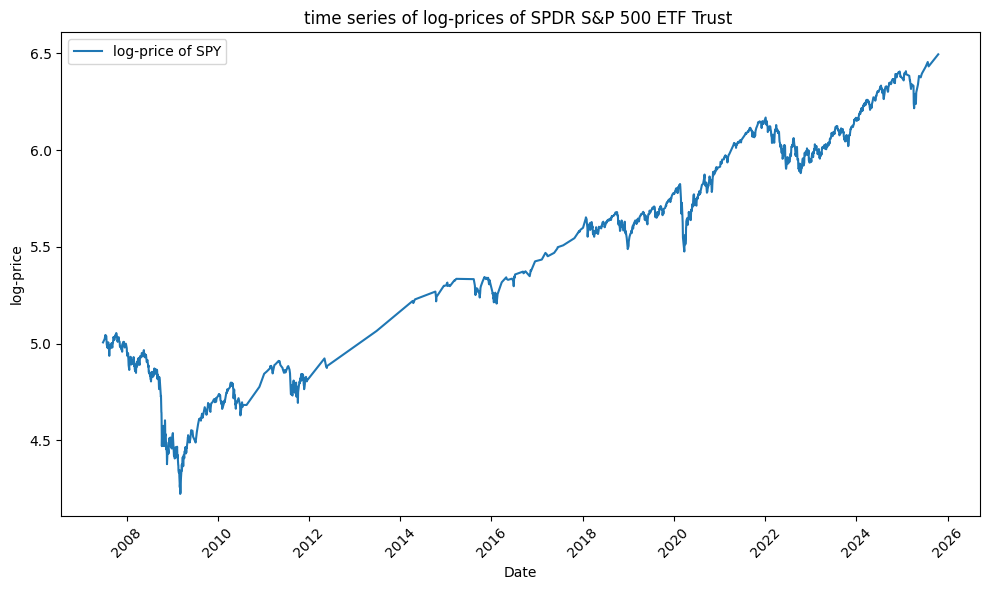

one could identify the crises: 2009, 2020 and 2022-2023
ok


In [242]:
#plot spy as index of the worlds economy

plt.figure(figsize=(10,6))

x=dates_cleaned

y1=(data_all_stocks["log_value_SPY"].drop(large_ev_1_indices).reset_index(drop=True)).apply(lambda x: np.mean(x)-np.log(10000)) 
# remove extra factor 10000 from Lobster and take log-price mean for each day
plt.plot(x, y1, label="log-price of SPY")

plt.xlabel("Date")
plt.ylabel("log-price")
plt.title("time series of log-prices of SPDR S&P 500 ETF Trust ")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("one could identify the crises: 2009, 2020 and 2022-2023")

print("ok")

Number of considered days in a):  1849
Number of business days in the period in a): 4777
Number of considered days in b):  358
Number of business days in the period in b): 587


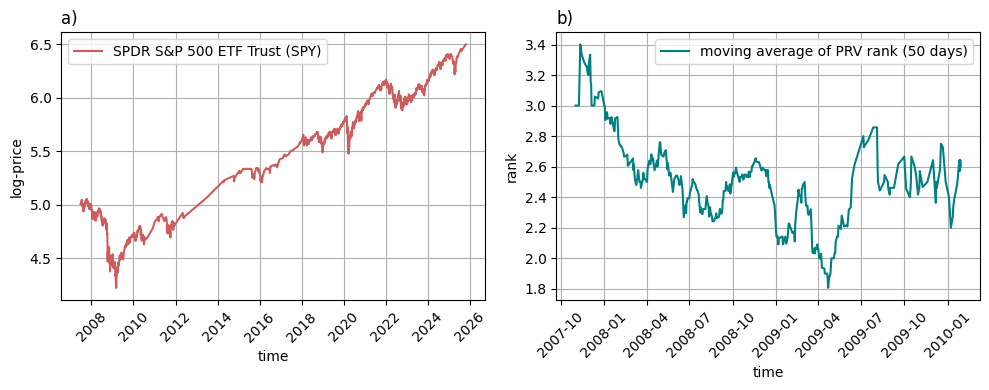

ok


In [243]:
#plot for thesis

#financial crisis: SPY and moving average of rank PRV

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) SPY
x=data_all_stocks["Datum"].drop(large_ev_1_indices).reset_index(drop=True).to_numpy()
y1=data_all_stocks["log_value_SPY"].drop(large_ev_1_indices).reset_index(drop=True).apply(lambda x: np.mean(x)-np.log(10000)) 
# remove extra factor 10000 from Lobster and take log-price mean for each day

ax1.plot(x, y1, label="SPDR S&P 500 ETF Trust (SPY)", color="indianred")

ax1.set_xlabel("time")
ax1.set_ylabel("log-price")
ax1.set_title("a) ", loc="left")
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='x',rotation=45)

start_day= pd.Timestamp(x[0]).date()
end_day= pd.Timestamp(x[-1]).date()
print("Number of considered days in a): ", len(x)) 
print("Number of business days in the period in a):", np.busday_count(start_day, end_day))


#b) rank with 30 days moving average
mov_av_data_full=data_all_stocks[["Datum"]].drop(large_ev_1_indices).reset_index(drop=True).copy()
mov_av_data_full["ranks_prv"]=ranks_of_prv_cleaned
mov_av_data_full["ranks_rv"]=ranks_of_rv_cleaned

#only the time between
start_day="2007-11-01"
end_day="2010-01-30"

mov_av_data=mov_av_data_full[(mov_av_data_full["Datum"]>= start_day) & (mov_av_data_full["Datum"]<= end_day)].copy()

print("Number of considered days in b): ", mov_av_data.shape[0]) 
print("Number of business days in the period in b):", np.busday_count(start_day, end_day))

mov_av_data = mov_av_data.sort_values("Datum") #sort for dates
mov_av_data = mov_av_data.set_index("Datum") # set dates as index

prv_rank_mov_avg=mov_av_data["ranks_prv"].rolling("50D").mean() 
#only consider 30 days before the date and take the average of the contained values
rv_rank_mov_avg=mov_av_data["ranks_rv"].rolling("50D").mean()


x=mov_av_data.index.to_numpy()
y1=prv_rank_mov_avg


ax2.plot(x, y1, label="moving average of PRV rank (50 days)", color="teal")

ax2.set_xlabel("time")
ax2.set_ylabel("rank")
ax2.legend()
ax2.tick_params(axis='x',rotation=45)
ax2.set_title("b)", loc="left")
ax2.grid(True)

plt.tight_layout()
plt.show()

fig.savefig("real_data_spy_mov_avg.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()

print("ok")

In [244]:
x[0]

numpy.datetime64('2007-11-02T00:00:00.000000000')

In [245]:
##############################
#now: d=14
############################## 
    

In [246]:
#create one big data frame

all_tickers = ["AMZN","EXC","GOOG","INTC","JNJ","JPM","MMM","MSFT","NVDA","PG","SPY","TSLA","XOM"]
all_data_frames = [data_processed_AMZN, data_processed_EXC, data_processed_GOOG, data_processed_INTC,
               data_processed_JNJ, data_processed_JPM, data_processed_MMM, data_processed_MSFT,
               data_processed_NVDA, data_processed_PG, data_processed_SPY, data_processed_TSLA,
               data_processed_XOM]
                   
unwanted_stock_positions=[]  
#[]=all, [1]= not EXC
#[1,4,11] is not bad: 1582 days, [1,2,4,11]: 2014 days and 10 stocks (=final choice), [1,2,3,4,8,11]: 2536 days

tickers=[ticker for ind, ticker in enumerate(all_tickers) if ind not in unwanted_stock_positions]
data_frames=[frame for ind, frame in enumerate(all_data_frames) if ind not in unwanted_stock_positions]


data_all_stocks = data_processed_AAPL.copy()

for df, ticker in zip(data_frames, tickers): #merge the data of all stocks iteratively, as merge only works with 2 data frames
    data_all_stocks = data_all_stocks.merge(df, how="inner", on="Datum", suffixes=("", f"_{ticker}"))
    #find dates which are fully observed for both data frames (how="inner", 
    #then use this date as date and use all the log-values and observation numbers as columns

data_all_stocks.rename(columns={
    "log_value": "log_value_AAPL",
    "number observations": "number observations_AAPL",
}, inplace=True)
#rename AAPL columns


print("shape of final data frame - data_all_stocks: ",data_all_stocks.shape)
print("number of stocks: ", len(tickers)+1, " , number of days: ", data_all_stocks.shape[0] )
print("head of data_all_stocks: ")
display(data_all_stocks.head())

log_cols = [col for col in data_all_stocks.columns if col.startswith("log_value")]
print("names of the columns with log-values: ",log_cols)

#tickers
#['AAPL','AMZN','EXC','GOOG','INTC','JNJ','JPM','MMM','MSFT','NVDA','PG','SPY','TSLA','XOM']
print("ok")

shape of final data frame - data_all_stocks:  (289, 29)
number of stocks:  14  , number of days:  289
head of data_all_stocks: 


,Datum,log_value_AAPL,number observations_AAPL,log_value_AMZN,number observations_AMZN,log_value_EXC,number observations_EXC,log_value_GOOG,number observations_GOOG,log_value_INTC,...,log_value_NVDA,number observations_NVDA,log_value_PG,number observations_PG,log_value_SPY,number observations_SPY,log_value_TSLA,number observations_TSLA,log_value_XOM,number observations_XOM
0,2010-07-01,"[14.749444725011024, 14.747280860686816, 14.74...",195,"[13.909365133435898, 13.916350872890346, 13.89...",195,"[12.842120234049546, 12.839735179255227, 12.84...",195,"[15.308953834601208, 15.30971717627856, 15.313...",195,"[12.177158635365531, 12.174581978438804, 12.17...",...,"[11.5376180775606, 11.534686956751742, 11.5366...",195,"[13.301513243032648, 13.300844234812345, 13.30...",195,"[13.846524611493443, 13.845651714876261, 13.84...",195,"[12.431613321444106, 12.423600458058747, 12.41...",195,"[13.25321618582309, 13.255669744712554, 13.256...",195
1,2011-06-15,"[15.008675163573606, 15.006702027925478, 15.00...",195,"[14.453039314761208, 14.454571072620453, 14.44...",195,"[12.93723789327764, 12.938680894971032, 12.937...",195,"[15.434958205427673, 15.435987317513591, 15.43...",195,"[12.28626918752445, 12.283033686666302, 12.285...",...,"[12.037062102795892, 12.010665849187564, 12.01...",195,"[13.37700559577791, 13.375764515879235, 13.374...",195,"[14.0643998256969, 14.063151580878872, 14.0640...",195,"[12.557785297639091, 12.552141543681682, 12.55...",195,"[13.586474680945226, 13.585216502621224, 13.58...",195
2,2011-08-03,"[15.178561880353765, 15.178510703281082, 15.17...",195,"[14.570223094182374, 14.563287959175334, 14.55...",195,"[12.982641434229192, 12.976412321920025, 12.97...",195,"[15.597219691338827, 15.60357989368343, 15.603...",195,"[12.283033686666302, 12.280252043704426, 12.28...",...,"[11.882417912619575, 11.881726588706801, 11.88...",195,"[13.31710745419684, 13.316942831593785, 13.316...",195,"[14.043920218950984, 14.044158929912928, 14.04...",195,"[12.52379883933033, 12.528156144699286, 12.527...",195,"[13.567305576054693, 13.566792755530633, 13.56...",195
3,2011-08-04,"[15.175409607724633, 15.178485113762548, 15.17...",195,"[14.521080258522776, 14.54600169166464, 14.530...",195,"[12.975949358948792, 12.966177294215, 12.96007...",195,"[15.59806108810702, 15.603061182418275, 15.603...",195,"[12.278858315255821, 12.282570616502898, 12.28...",...,"[11.887243844081556, 11.878956503832987, 11.87...",195,"[13.312818434095005, 13.315624874236617, 13.31...",195,"[14.034003311063056, 14.034726405940503, 14.03...",195,"[12.487485104968359, 12.484461671070362, 12.48...",195,"[13.549981290153626, 13.548153851973739, 13.54...",195
4,2011-08-05,"[15.151668849590367, 15.157983639535315, 15.15...",195,"[14.528656425030908, 14.511304233465125, 14.50...",195,"[12.930233879619289, 12.954181384164093, 12.95...",195,"[15.578476099026682, 15.585876134504657, 15.58...",195,"[12.255338886833092, 12.25819059979228, 12.254...",...,"[11.828465865550406, 11.830651658770385, 11.83...",195,"[13.324487561494463, 13.317272049703755, 13.31...",195,"[14.012392266089558, 14.01436141670944, 14.012...",195,"[12.429616116865711, 12.436390400592384, 12.43...",195,"[13.52822840553382, 13.531422021022623, 13.528...",195


names of the columns with log-values:  ['log_value_AAPL', 'log_value_AMZN', 'log_value_EXC', 'log_value_GOOG', 'log_value_INTC', 'log_value_JNJ', 'log_value_JPM', 'log_value_MMM', 'log_value_MSFT', 'log_value_NVDA', 'log_value_PG', 'log_value_SPY', 'log_value_TSLA', 'log_value_XOM']
ok


In [247]:
#analysis of estimators

n=int(data_all_stocks.iloc[0,2])
print("number of observations per stock per day: n=", n)

number_of_stocks=int(len(log_cols))
d=number_of_stocks
print("number of observed stocks: d=", number_of_stocks)

number_of_days=data_all_stocks.shape[0]
print("number of observed days: ", number_of_days)

#arays to contain results
ranks_of_prv=np.zeros(number_of_days)
ranks_of_rv=np.zeros(number_of_days)

ev_rv=np.zeros((number_of_days,number_of_stocks))
ev_prv=np.zeros((number_of_days,number_of_stocks))

normed_ev_rv=np.zeros((number_of_days,number_of_stocks))
normed_ev_prv=np.zeros((number_of_days,number_of_stocks))


#iterate over all days(rows) in the data frame:
for idx, row in data_all_stocks.iterrows():
    log_values=np.zeros((n, number_of_stocks))   #observations with each column is a stock, each row a time
    for z in range(number_of_stocks):
        log_values[:, z]=np.array(data_all_stocks[log_cols[z]].iloc[idx]) 
    log_price_increments=np.diff(log_values, axis=0)   #caluclate the i-th row minus the (i-1)-th
    rv=fast_realized_variance(log_price_increments)
    ranks_of_rv[idx]=np.linalg.matrix_rank(rv)
    tuning_parameter_lambda=lambda_selection_via_subsampling_procedure(log_price_increments, L_lambda=6)
    prv, ranks_of_prv[idx]=penalized_realized_variance_for_given_lambda_and_RV(rv, tuning_parameter_lambda)
    ev_prv_day=np.sort(np.linalg.eigvalsh(prv))[::-1] #sorted in decreasing order: [::-1]
    ev_rv_day=np.sort(np.linalg.eigvalsh(rv))[::-1]
    ev_prv[idx,:]=ev_prv_day
    ev_rv[idx,:]=ev_rv_day
    normed_ev_prv[idx,:]=ev_prv_day/np.sum(ev_prv_day)
    normed_ev_rv[idx,:]=ev_rv_day/np.sum(ev_rv_day)
    
    if idx % (math.floor(number_of_days/10))==0:
        print(f'Finished day {idx+1} of {number_of_days}.')
        
#test
#print(log_values.shape, log_price_increments.shape) 
#print(log_values[0:5,0:5])
#print(log_price_increments[0:5,0:5])

print("ok")

number of observations per stock per day: n= 195
number of observed stocks: d= 14
number of observed days:  289
Finished day 1 of 289.
Finished day 29 of 289.
Finished day 57 of 289.
Finished day 85 of 289.
Finished day 113 of 289.
Finished day 141 of 289.
Finished day 169 of 289.
Finished day 197 of 289.
Finished day 225 of 289.
Finished day 253 of 289.
Finished day 281 of 289.
ok


In [248]:
#fast rank analysis
#which ranks of the prv appear how often
values, counts = np.unique(ranks_of_prv, return_counts=True)
relative_counts=counts/np.sum(counts)
print("prv ranks:", values)
print("how often:", counts)
print("relative:",relative_counts)
print("rank mean: ", np.mean(ranks_of_prv))
print("number of ranks in total (=observed days):", np.sum(counts))
print("ok")

prv ranks: [1. 2. 3. 4. 5.]
how often: [ 45  85 101  55   3]
relative: [0.15570934 0.29411765 0.34948097 0.19031142 0.01038062]
rank mean:  2.605536332179931
number of ranks in total (=observed days): 289
ok


In [249]:
#exclude days with extremely high ev1

large_ev_1_indices_matrix= (np.where(ev_rv[:, 0]>10**(-1))[0])
large_ev_1_indices=large_ev_1_indices_matrix.flatten()
print("shape of large_ev_1_indices:", large_ev_1_indices.shape)

dates_cleaned=data_all_stocks["Datum"].drop(large_ev_1_indices).reset_index(drop=True) 
#index is made new without missing values in between

#here: extra "_all_stocks"
ranks_of_prv_cleaned_all_stocks=np.delete(ranks_of_prv, large_ev_1_indices, axis=0)
ranks_of_rv_cleaned_all_stocks=np.delete(ranks_of_rv, large_ev_1_indices, axis=0)

ev_prv_cleaned=np.delete(ev_prv, large_ev_1_indices, axis=0)
ev_rv_cleaned=np.delete(ev_rv, large_ev_1_indices, axis=0)

normed_ev_prv_cleaned=np.delete(normed_ev_prv, large_ev_1_indices, axis=0)
normed_ev_rv_cleaned=np.delete(normed_ev_rv, large_ev_1_indices, axis=0)

print("shape of dates_cleaned:",dates_cleaned.shape)
print("shape of ev_prv_cleaned:", np.shape(ev_prv_cleaned))

print("ok")


shape of large_ev_1_indices: (22,)
shape of dates_cleaned: (267,)
shape of ev_prv_cleaned: (267, 14)
ok


In [250]:
#fast rank analysis
#which ranks of the prv appear how often
values, counts = np.unique(ranks_of_prv_cleaned, return_counts=True)
relative_counts=counts/np.sum(counts)
print("prv ranks:", values)
print("how often:", counts)
print("=> cleaning only deleted rank 1 prv estimators.")
print("relative:",relative_counts)
print("rank mean: ", np.mean(ranks_of_prv_cleaned))
print("number of ranks in total (=observed days):", np.sum(counts))
print("ok")

prv ranks: [1. 2. 3. 4. 5. 6.]
how often: [208 543 835 222  38   3]
=> cleaning only deleted rank 1 prv estimators.
relative: [0.11249324 0.29367226 0.45159546 0.1200649  0.02055165 0.0016225 ]
rank mean:  2.6473769605191997
number of ranks in total (=observed days): 1849
ok


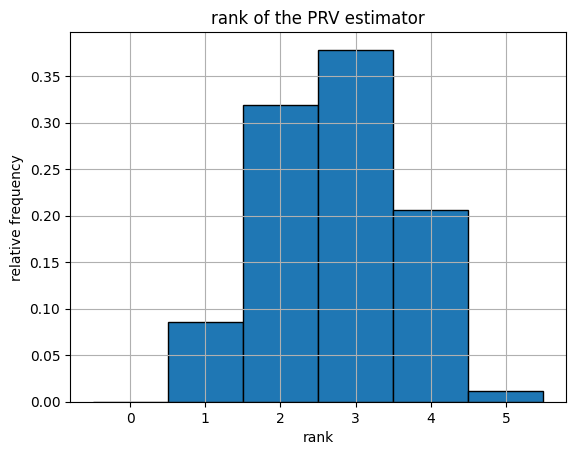

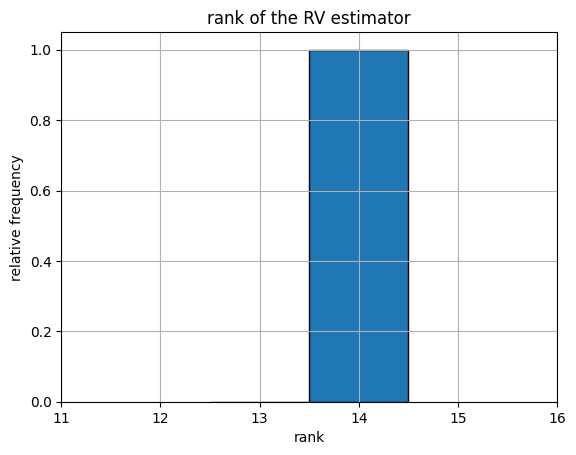

observed days:  1849
PRV rank fits well to Fama-French three factor interpretation of data
ok


In [251]:
#histogram of prv ranks
ranks=ranks_of_prv_cleaned_all_stocks
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 2) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
plt.hist(ranks, bins=bins_def, density=True, edgecolor='black')  #density for relative


plt.title('rank of the PRV estimator')
plt.xlabel("rank")
plt.ylabel("relative frequency")
plt.grid(True)

plt.show()

ranks=ranks_of_rv_cleaned_all_stocks
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 2) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
plt.hist(ranks, bins=bins_def, density=True, edgecolor='black')     #density for relative
plt.xticks(range(11,17))
plt.title("rank of the RV estimator")
plt.xlabel("rank")
plt.ylabel("relative frequency")
plt.grid(True)

plt.show()

print("observed days: ",ranks_of_prv_cleaned.shape[0])
print("PRV rank fits well to Fama-French three factor interpretation of data")

print("ok")

Number of observed days in a):  1849
Mean of observed ranks in a):  2.6473769605191997
Number of observed days in b):  267
Mean of observed ranks in b):  2.737827715355805


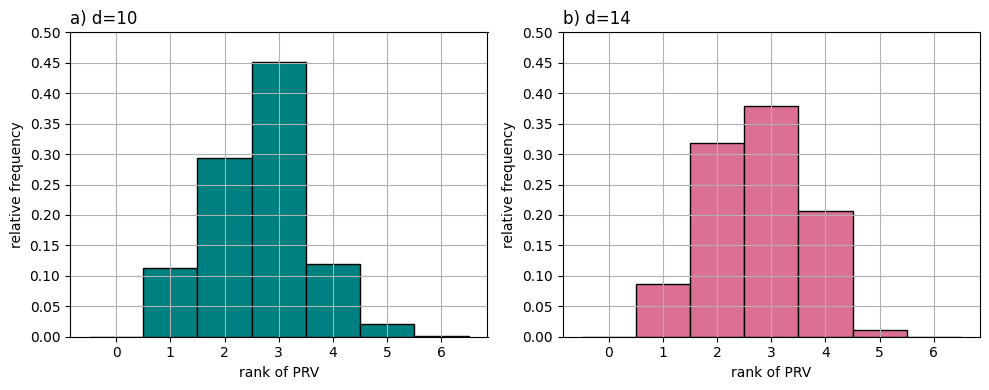

PRV rank fits well to Fama-French three factor interpretation of data in both cases.
For d=14: 8% shift from rank 3 to 4, 3% shift from rank 1 to 2. Interesting: less rank 5 or 6 for higher dimension d=14.
ok


In [252]:
#plots for export


#histograms of PRV ranks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) d=10 (=number of stocks)

#histogram of prv ranks
ranks=ranks_of_prv_cleaned
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 2) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
ax1.hist(ranks, bins=bins_def, density=True, edgecolor='black', color="teal")  #density for relative

ax1.set_xlabel("rank of PRV")
ax1.set_ylabel("relative frequency")
ax1.set_title("a) d=10 ", loc="left")
ax1.grid(True)
ax1.set_yticks(np.arange(0, 0.55, 0.05))

print("Number of observed days in a): ",ranks_of_prv_cleaned.shape[0])
print("Mean of observed ranks in a): ",np.mean(ranks_of_prv_cleaned))


#b) d=14 (=number of stocks)

#histogram of prv ranks
ranks=ranks_of_prv_cleaned_all_stocks
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 3) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
ax2.hist(ranks, bins=bins_def, density=True, edgecolor='black', color="palevioletred")  #density for relative

ax2.set_xlabel("rank of PRV")
ax2.set_ylabel("relative frequency")
ax2.set_title("b) d=14 ", loc="left")
ax2.grid(True)
ax2.set_yticks(np.arange(0, 0.55, 0.05))

print("Number of observed days in b): ",ranks_of_prv_cleaned_all_stocks.shape[0])
print("Mean of observed ranks in b): ",np.mean(ranks_of_prv_cleaned_all_stocks))

plt.tight_layout()
plt.show()

fig.savefig("real_data_prv_ranks_hist.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()


print("PRV rank fits well to Fama-French three factor interpretation of data in both cases.")
print("For d=14: 8% shift from rank 3 to 4, 3% shift from rank 1 to 2. Interesting: less rank 5 or 6 for higher dimension d=14.")

print("ok")

In [253]:
#test
#print(data_all_stocks[log_cols[0]].iloc[0])